# Eksplorasi Fitur TSFEL (Anggota 3)
**Tujuan Notebook ini:**
1. Mengekstrak fitur statistik menggunakan library `tsfel`.
2. Menganalisis masalah umum dari ekstraksi (seperti munculnya nilai `inf` atau `NaN`).
3. Membersihkan fitur-fitur tersebut.
4. Melihat korelasi fitur mana yang paling kuat pengaruhnya terhadap deteksi kerusakan ESP (`Is_Anomaly`).

In [1]:
import pandas as pd
import numpy as np
import tsfel
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil dimuat!")

Library berhasil dimuat!


In [4]:
import pandas as pd
import numpy as np

print("Memuat data yang SUDAH dibersihkan untuk Ekstraksi TSFEL...")

# 1. Definisikan secara eksplisit kolom-kolom yang ingin kita pakai
kolom_yang_dipakai = [
    'Well_ID',           # Identitas Sumur
    'Is_Anomaly',        # Target (Pengganti Downtime)
    'Freq_Norm',         # Pengganti Frequency
    'Current_Norm',      # Pengganti Load
    'Vibration_Norm', 
    'Gas_Sat_Norm', 
    'Intake_Press_Norm', 
    'Motor_Temp_Norm', 
    'Delta_Press_Norm', 
    'Pwr_Diff_Norm', 
    'Liq_Intake_Norm'
]

# 2. Baca file matang menggunakan usecols
df = pd.read_csv(
    r'C:\Users\hatta\ESP-FAILURE-DETECTION\Data\Processed\processed_data.csv', 
    usecols=kolom_yang_dipakai
)

# 3. Cek jumlah anomali untuk memastikan target tidak hilang
print(f"Jumlah Kasus Normal (0): {len(df[df['Is_Anomaly'] == 0])}")
print(f"Jumlah Kasus Anomali (1): {len(df[df['Is_Anomaly'] == 1])}")

# Langkah pengamanan ekstra: pastikan tidak ada nilai infinity (inf) yang tersisa
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

print(f"\nData siap diekstrak TSFEL! Jumlah sampel akhir: {df.shape[0]}")
display(df.head())

Memuat data yang SUDAH dibersihkan untuk Ekstraksi TSFEL...
Jumlah Kasus Normal (0): 279
Jumlah Kasus Anomali (1): 39895

Data siap diekstrak TSFEL! Jumlah sampel akhir: 40174


,Well_ID,Is_Anomaly,Freq_Norm,Vibration_Norm,Gas_Sat_Norm,Current_Norm,Intake_Press_Norm,Motor_Temp_Norm,Delta_Press_Norm,Pwr_Diff_Norm,Liq_Intake_Norm
0,2.0,1,0.199514,0.862201,0.123392,0.845357,0.0,0.881972,88.356532,2.363394,3.876404
1,0.0,1,0.229176,0.839019,0.123392,1.048205,0.0,0.988554,13.605535,2.254770,3.254717
2,0.0,1,0.203029,0.811594,0.123392,1.050555,0.0,0.931359,14.449174,1.799861,3.254717
3,0.0,1,0.201952,0.811594,0.123392,1.045526,0.0,1.013480,13.963023,1.697855,3.254717
4,0.0,1,0.200912,0.811594,0.123392,1.043627,0.0,0.972905,14.317242,1.689167,3.254717


In [6]:
print("Memulai ekstraksi TSFEL...")

# Kita ambil fitur domain statistik saja agar komputasi ringan
cgf_settings = tsfel.get_features_by_domain('statistical')

fitur_sensor = [
    'Freq_Norm', 'Current_Norm', 'Vibration_Norm', 'Gas_Sat_Norm', 
    'Intake_Press_Norm', 'Motor_Temp_Norm', 'Delta_Press_Norm', 
    'Pwr_Diff_Norm', 'Liq_Intake_Norm'
]

df_features = tsfel.time_series_features_extractor(
    cgf_settings, 
    df[fitur_sensor], 
    window_size=1, 
    verbose=1
)

print(f"\nEkstraksi selesai! TSFEL menghasilkan {df_features.shape[1]} kolom baru.")
df_features.head()

Memulai ekstraksi TSFEL...



Ekstraksi selesai! TSFEL menghasilkan 198 kolom baru.


,Current_Norm_Absolute energy,Current_Norm_Average power,Current_Norm_ECDF Percentile Count_0,Current_Norm_ECDF Percentile Count_1,Current_Norm_ECDF Percentile_0,Current_Norm_ECDF Percentile_1,Current_Norm_ECDF_0,Current_Norm_Entropy,Current_Norm_Histogram mode,Current_Norm_Interquartile range,...,Vibration_Norm_Mean,Vibration_Norm_Mean absolute deviation,Vibration_Norm_Median,Vibration_Norm_Median absolute deviation,Vibration_Norm_Min,Vibration_Norm_Peak to peak distance,Vibration_Norm_Root mean square,Vibration_Norm_Skewness,Vibration_Norm_Standard deviation,Vibration_Norm_Variance
0,0.714628,inf,0.845357,0.845357,0.845357,0.845357,1.0,NaN,0.895357,0.0,...,0.862201,0.0,0.862201,0.0,0.862201,0.0,0.862201,NaN,0.0,0.0
1,1.098733,inf,1.048205,1.048205,1.048205,1.048205,1.0,NaN,1.098205,0.0,...,0.839019,0.0,0.839019,0.0,0.839019,0.0,0.839019,NaN,0.0,0.0
2,1.103666,inf,1.050555,1.050555,1.050555,1.050555,1.0,NaN,1.100555,0.0,...,0.811594,0.0,0.811594,0.0,0.811594,0.0,0.811594,NaN,0.0,0.0
3,1.093126,inf,1.045526,1.045526,1.045526,1.045526,1.0,NaN,1.095526,0.0,...,0.811594,0.0,0.811594,0.0,0.811594,0.0,0.811594,NaN,0.0,0.0
4,1.089158,inf,1.043627,1.043627,1.043627,1.043627,1.0,NaN,1.093627,0.0,...,0.811594,0.0,0.811594,0.0,0.811594,0.0,0.811594,NaN,0.0,0.0


In [7]:
# Cek nilai Infinity (Tak Terhingga)
inf_counts = np.isinf(df_features).sum().sum()
# Cek nilai NaN (Kosong)
nan_counts = df_features.isna().sum().sum()

print(f"Ditemukan {inf_counts} nilai Infinity (inf) di seluruh data.")
print(f"Ditemukan {nan_counts} nilai kosong (NaN) di seluruh data.")

# Jika ada, KITA WAJIB MEMBERSIHKANNYA sebelum dikasih ke Anggota 4
df_features_clean = df_features.replace([np.inf, -np.inf], np.nan)
df_features_clean = df_features_clean.fillna(0)

print("\nPembersihan selesai. Data fitur sudah bersih dari inf/NaN.")

Ditemukan 342745 nilai Infinity (inf) di seluruh data.
Ditemukan 1103519 nilai kosong (NaN) di seluruh data.

Pembersihan selesai. Data fitur sudah bersih dari inf/NaN.


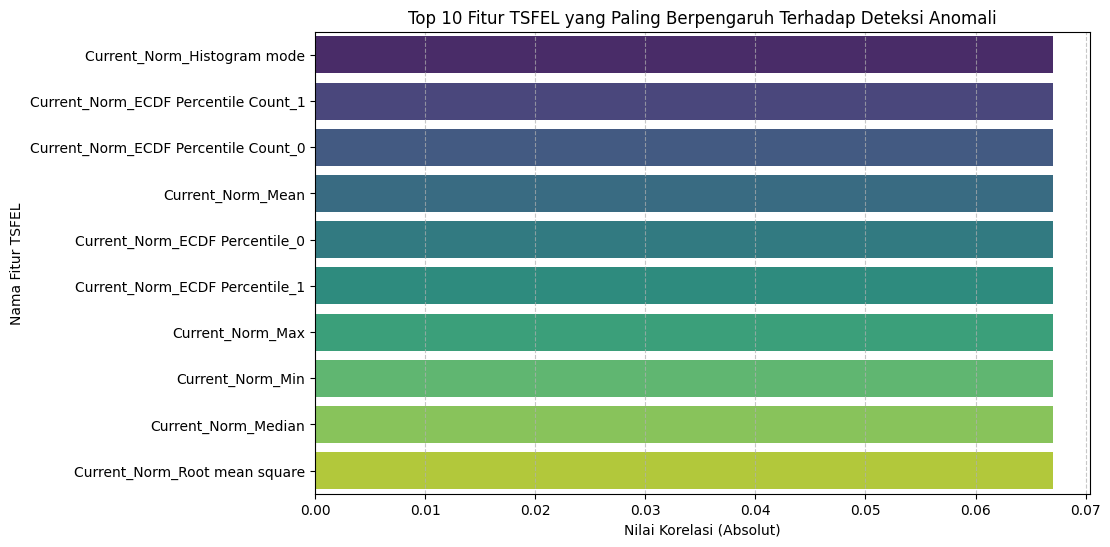

In [8]:
# Gabungkan fitur yang sudah bersih dengan label target
df_combined = pd.concat([df_features_clean.reset_index(drop=True), df['Is_Anomaly'].reset_index(drop=True)], axis=1)

# Hitung korelasi semua fitur terhadap 'Is_Anomaly'
correlation_matrix = df_combined.corr()
target_corr = correlation_matrix['Is_Anomaly'].drop('Is_Anomaly') # Buang korelasi dengan dirinya sendiri

# Ambil 10 fitur dengan korelasi terkuat (baik positif maupun negatif)
top_10_features = target_corr.abs().sort_values(ascending=False).head(10)

# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis')
plt.title('Top 10 Fitur TSFEL yang Paling Berpengaruh Terhadap Deteksi Anomali')
plt.xlabel('Nilai Korelasi (Absolut)')
plt.ylabel('Nama Fitur TSFEL')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()